In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. SETTINGS & REPRODUCIBILITY
np.random.seed(42)
n_devices = 500
n_alerts = 2500

# 2. GENERATE DEVICES TABLE
def generate_devices(n):
    device_ids = [f"DEV-{i:05d}" for i in range(10001, 10001 + n)]
    # Updated: Matches 70/20/10 mix from Section 3.4
    os_types = np.random.choice(['Windows', 'Linux', 'MacOS'], size=n, p=[0.70, 0.20, 0.10])
    # Updated: Matches p=0.30 from document
    is_at_risk = np.random.binomial(n=1, p=0.30, size=n)
    # Updated: Matches p=0.10 (The 1:10 Server Ratio)
    is_server = np.random.binomial(n=1, p=0.10, size=n)
    patch_age = np.random.poisson(lam=14, size=n)

    return pd.DataFrame({
        'device_id': device_ids,
        'os_type': os_types,
        'is_at_risk': is_at_risk,
        'is_server': is_server,
        'patch_age': patch_age
    })

# 3. GENERATE ALERTS & OUTCOMES
def generate_alerts_and_outcomes(devices_df, n_alerts):
    alert_ids = [f"ALR-{i:05d}" for i in range(20001, 20001 + n_alerts)]
    device_sample = devices_df.sample(n_alerts, replace=True).reset_index(drop=True)

    # Added: Timestamps for Off-Hours analysis (Section 6)
    start_date = datetime(2026, 3, 1)
    timestamps = [start_date + timedelta(
        days=np.random.randint(0, 30),
        hours=np.random.randint(0, 24),
        minutes=np.random.randint(0, 60)
    ) for _ in range(n_alerts)]

    severity = np.random.randint(1, 6, size=n_alerts)
    sig_ids = np.random.randint(1000000, 2000000, size=n_alerts)
    is_off_hours = np.random.binomial(n=1, p=0.35, size=n_alerts)
    latent_persistence = np.random.beta(a=2, b=5, size=n_alerts)

    # The "Brain" (Updated Logit Logic)
    # b0=-4.5 creates the ~93-95% False Positive rate (Noise)
    # b1=1.95 is the Logit of 7 (The 7x Risk Multiplier)
    # b2=1.1 adds weight for Servers
    # b3=0.5 adds weight for Off-Hours
    b0, b1, b2, b3, b4 = -4.5, 1.95, 1.1, 0.5, 4.5
    logit = (b0 +
             (b1 * device_sample['is_at_risk']) +
             (b2 * device_sample['is_server']) +
             (b3 * is_off_hours) +
             (b4 * latent_persistence))

    tp_prob = 1 / (1 + np.exp(-logit))
    true_positives = np.random.binomial(n=1, p=tp_prob)

    alerts_df = pd.DataFrame({
        'alert_id': alert_ids,
        'device_id': device_sample['device_id'],
        'timestamp': timestamps,
        'severity_score': severity,
        'signature_id': sig_ids,
        'is_off_hours': is_off_hours
    })

    outcomes_df = pd.DataFrame({
        'outcome_id': [f"OUT-{i:05d}" for i in range(30001, 30001 + n_alerts)],
        'alert_id': alert_ids,
        'true_positive_flag': true_positives,
        'confidence_score': np.clip(np.random.normal(0.7, 0.15, n_alerts), 0, 1),
        'latent_persistence': latent_persistence
    })

    return alerts_df, outcomes_df

# 4. GENERATE RESPONSE ACTIONS
def generate_responses(alerts_df, outcomes_df):
    n = len(alerts_df)
    actions = ['Isolate Host', 'Apply Patch', 'Remove Malware', 'Dismiss as Noise']
    seniority = np.random.randint(1, 4, n)

    action_types = []
    for tp in outcomes_df['true_positive_flag']:
        if tp == 1:
            p = [0.4, 0.1, 0.4, 0.1]
        else:
            p = [0.05, 0.1, 0.05, 0.8]
        action_types.append(np.random.choice(actions, p=p))

    # Updated: Resolution time is now influenced by seniority
    # Senior (3) reduces mu more than Junior (1), making them faster
    base_mu = 2.5
    adjusted_mu = base_mu - (seniority * 0.15)
    res_times = [np.random.lognormal(m, 0.7) for m in adjusted_mu]

    return pd.DataFrame({
        'action_id': [f"ACT-{i:05d}" for i in range(40001, 40001 + n)],
        'alert_id': alerts_df['alert_id'],
        'analyst_id': [f"ANL-{np.random.randint(1, 21):03d}" for _ in range(n)],
        'action_type': action_types,
        'resolution_time_min': res_times,
        'analyst_seniority': seniority
    })

# --- EXECUTION ---
df_devices = generate_devices(n_devices)
df_alerts, df_outcomes = generate_alerts_and_outcomes(df_devices, n_alerts)
df_responses = generate_responses(df_alerts, df_outcomes)

# --- THE OMITTED VARIABLE STEP ---
# Calculate summary stats for Section 8 of the doc
tp_rate = df_outcomes['true_positive_flag'].mean()
print(f"Dataset generated with {tp_rate:.2%} True Positive Rate ({(1-tp_rate):.2%} Noise)")
df_outcomes = df_outcomes.drop(columns=['latent_persistence'])

# --- EXPORT ---
df_devices.to_csv('devices.csv', index=False)
df_alerts.to_csv('alerts.csv', index=False)
df_outcomes.to_csv('outcomes.csv', index=False)
df_responses.to_csv('responses.csv', index=False)

print("Success! All 4 tables exported to CSV.")

Dataset generated with 12.32% True Positive Rate (87.68% Noise)
Success! All 4 tables exported to CSV.


In [ ]:
import pandas as pd

# Load Raw Files
df_devices = pd.read_csv('devices.csv')
df_alerts = pd.read_csv('alerts.csv')
df_outcomes = pd.read_csv('outcomes.csv')
df_responses = pd.read_csv('responses.csv')

# 1. Feature Engineering
df_alerts['hour'] = pd.to_datetime(df_alerts['timestamp']).dt.hour
df_responses['seniority_label'] = df_responses['analyst_seniority'].map({1: 'Junior', 2: 'Mid-Level', 3: 'Senior'})
df_outcomes['outcome_label'] = df_outcomes['true_positive_flag'].map({1: 'True Positive', 0: 'False Positive'})

# 2. Master Merge (Inner/Left Joins)
df_clean = df_alerts.merge(df_devices, on='device_id', how='left')
df_clean = df_clean.merge(df_outcomes, on='alert_id', how='left')
df_clean = df_clean.merge(df_responses, on='alert_id', how='left')

# 3. Outlier Handling
# Identify "Complex Cases" as top 10% of resolution times
threshold = df_clean['resolution_time_min'].quantile(0.90)
df_clean['is_complex_case'] = df_clean['resolution_time_min'] > threshold

# 4. Integrity Check (Fill missing patch_age if any)
df_clean['patch_age'] = df_clean['patch_age'].fillna(df_clean['patch_age'].median())

def validate_data(df):
    # Check for negative resolution times (impossible in physics)
    assert (df['resolution_time_min'] > 0).all(), "Error: Negative resolution times detected!"

    # Check for invalid OS types
    valid_os = ['Windows', 'Linux', 'MacOS']
    assert df['os_type'].isin(valid_os).all(), "Error: Unknown OS detected!"

    # Check for alert_id uniqueness
    assert df['alert_id'].is_unique, "Error: Duplicate alert IDs found!"
    print("Data Validation Passed.")

# Call this at the end of Phase 2
validate_data(df_clean)

# EXPORT CLEAN MASTER FILE
df_clean.to_csv('cleaned_triage_data.csv', index=False)
print("Phase 2 Complete: Master 'cleaned_triage_data.csv' created.")

Data Validation Passed.
Phase 2 Complete: Master 'cleaned_triage_data.csv' created.


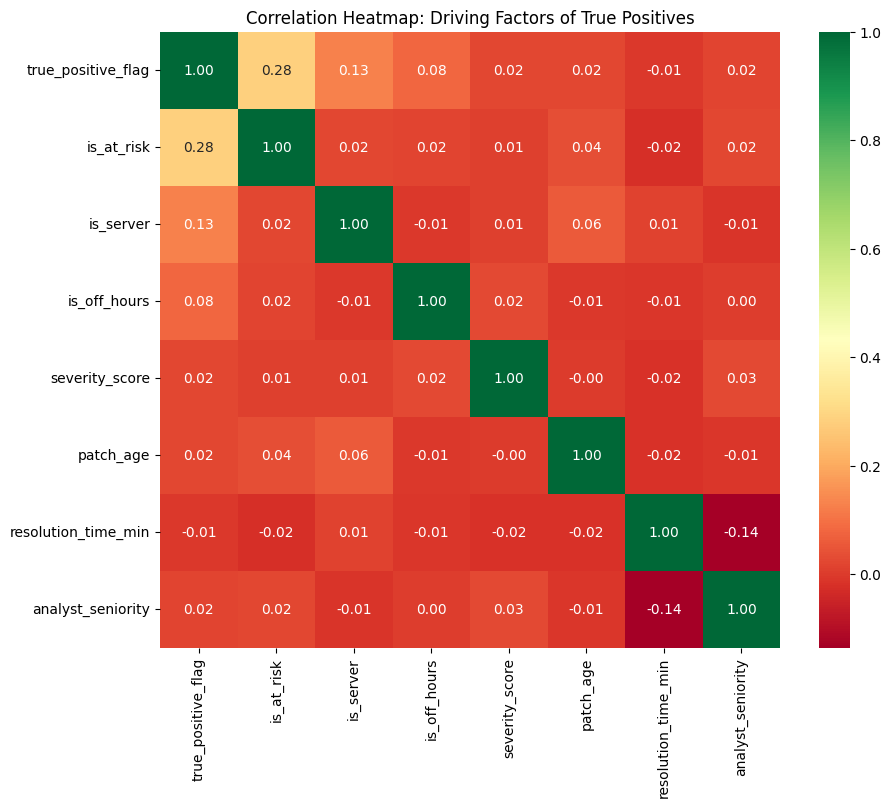

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Cleaned Data
df = pd.read_csv('cleaned_triage_data.csv')

# Correlation Analysis (Heatmap)
corr_cols = ['true_positive_flag', 'is_at_risk', 'is_server', 'is_off_hours',
             'severity_score', 'patch_age', 'resolution_time_min', 'analyst_seniority']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap: Driving Factors of True Positives')
plt.savefig('correlation_heatmap.png')
plt.show()

--- Off-Hours Significance Test ---
     Is Off-Hours  True Positive Rate  Total Alert Volume
0  Business Hours            0.103491                1604
1       Off-Hours            0.158482                 896


/tmp/ipykernel_10019/4155875273.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Is Off-Hours', y='True Positive Rate', data=off_hours_stats, palette='coolwarm')


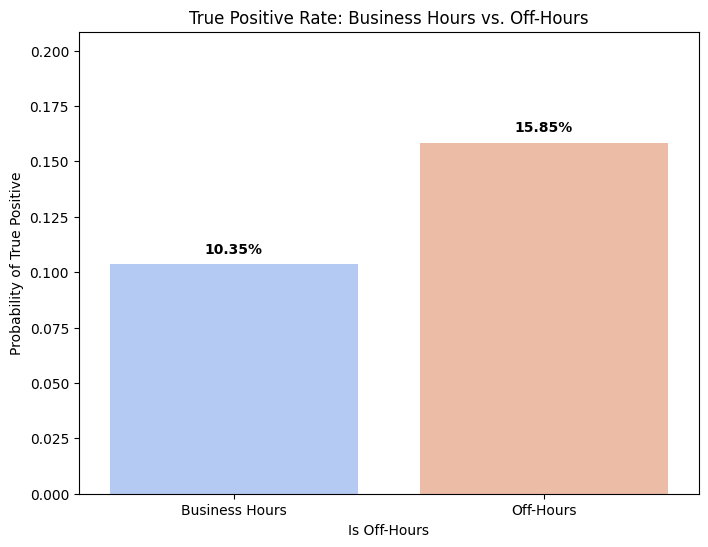

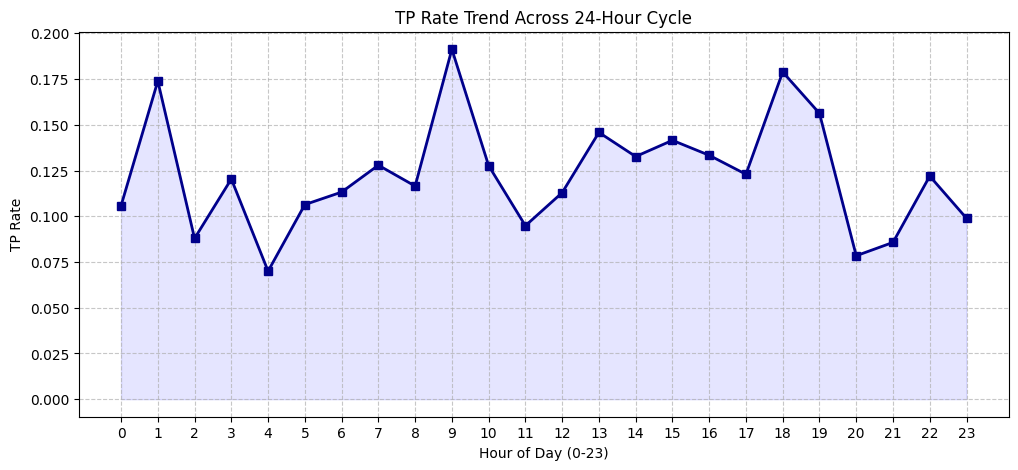

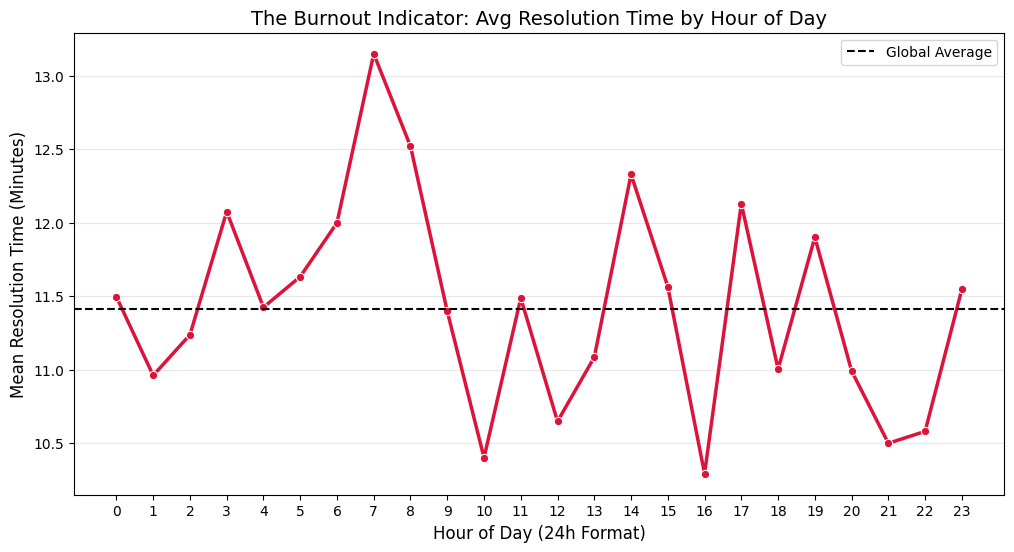

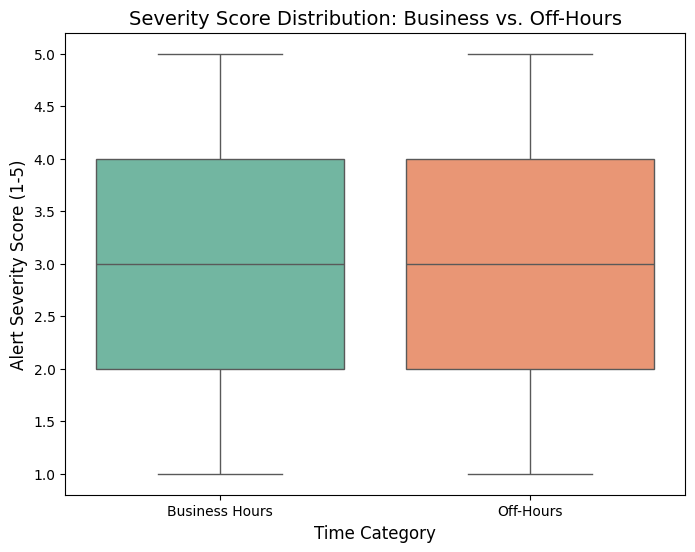


--- Severity Mean Comparison ---
Business Hours Mean Severity: 3.03
Off-Hours Mean Severity: 3.10


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Cleaned Data
df = pd.read_csv('cleaned_triage_data.csv')

# DO OFF HOURS MEAN TRUE POSITIVES?
# 1. Calculate the True Positive Rate for Business Hours vs Off-Hours
off_hours_stats = df.groupby('is_off_hours')['true_positive_flag'].agg(['mean', 'count']).reset_index()
off_hours_stats.columns = ['Is Off-Hours', 'True Positive Rate', 'Total Alert Volume']

# Convert 0/1 to readable labels
off_hours_stats['Is Off-Hours'] = off_hours_stats['Is Off-Hours'].map({0: 'Business Hours', 1: 'Off-Hours'})

print("--- Off-Hours Significance Test ---")
print(off_hours_stats)

# 2. Visualize the TP Rate Difference
plt.figure(figsize=(8, 6))
sns.barplot(x='Is Off-Hours', y='True Positive Rate', data=off_hours_stats, palette='coolwarm')

# Add labels to the bars for the report
for i, val in enumerate(off_hours_stats['True Positive Rate']):
    plt.text(i, val + 0.005, f'{val:.2%}', ha='center', fontweight='bold')

plt.title('True Positive Rate: Business Hours vs. Off-Hours')
plt.ylabel('Probability of True Positive')
plt.ylim(0, max(off_hours_stats['True Positive Rate']) + 0.05)
plt.savefig('off_hours_tp_comparison.png')
plt.show()

# 3. Deep Dive: Hourly TP Rate Trend
plt.figure(figsize=(12, 5))
hourly_tp = df.groupby('hour')['true_positive_flag'].mean()
hourly_tp.plot(kind='line', marker='s', color='darkblue', linewidth=2)
plt.fill_between(hourly_tp.index, hourly_tp, alpha=0.1, color='blue')
plt.title('TP Rate Trend Across 24-Hour Cycle')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('TP Rate')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('hourly_tp_trend.png')
plt.show()






# --- 1. THE BURNOUT INDICATOR ---
plt.figure(figsize=(12, 6))

# Line plot showing the average resolution time per hour
hourly_res = df.groupby('hour')['resolution_time_min'].mean()
sns.lineplot(x=hourly_res.index, y=hourly_res.values, marker='o', color='crimson', linewidth=2.5)

# Add a 'Mean' line for context
plt.axhline(df['resolution_time_min'].mean(), color='black', linestyle='--', label='Global Average')

plt.title('The Burnout Indicator: Avg Resolution Time by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (24h Format)', fontsize=12)
plt.ylabel('Mean Resolution Time (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.savefig('burnout_indicator_line.png')
plt.show()





# --- 2. THE OFF-HOURS SEVERITY EFFECT ---
plt.figure(figsize=(8, 6))

# Using a Boxplot to see the distribution of Severity Scores
sns.boxplot(x='is_off_hours', y='severity_score', data=df, palette='Set2', hue='is_off_hours', legend=False)

# Map labels for the X-axis
plt.xticks([0, 1], ['Business Hours', 'Off-Hours'])

plt.title('Severity Score Distribution: Business vs. Off-Hours', fontsize=14)
plt.xlabel('Time Category', fontsize=12)
plt.ylabel('Alert Severity Score (1-5)', fontsize=12)
plt.savefig('off_hours_severity_dist.png')
plt.show()

# Statistical Check
off_hours_sev = df.groupby('is_off_hours')['severity_score'].mean()
print("\n--- Severity Mean Comparison ---")
print(f"Business Hours Mean Severity: {off_hours_sev[0]:.2f}")
print(f"Off-Hours Mean Severity: {off_hours_sev[1]:.2f}")







/tmp/ipykernel_10019/668893996.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='patch_age_bins', y='true_positive_flag', data=df, palette='Reds')


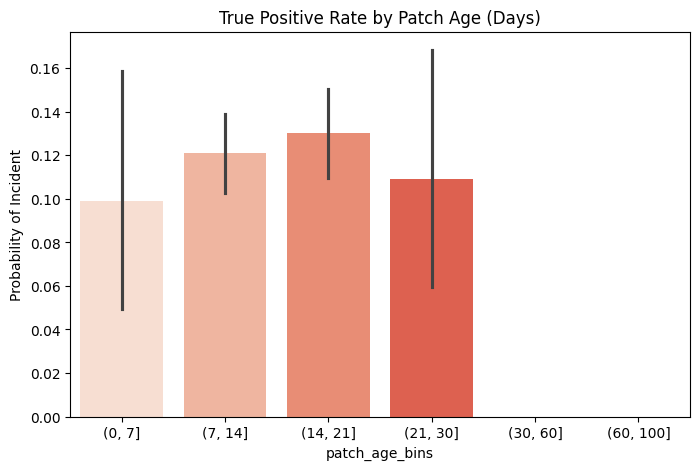

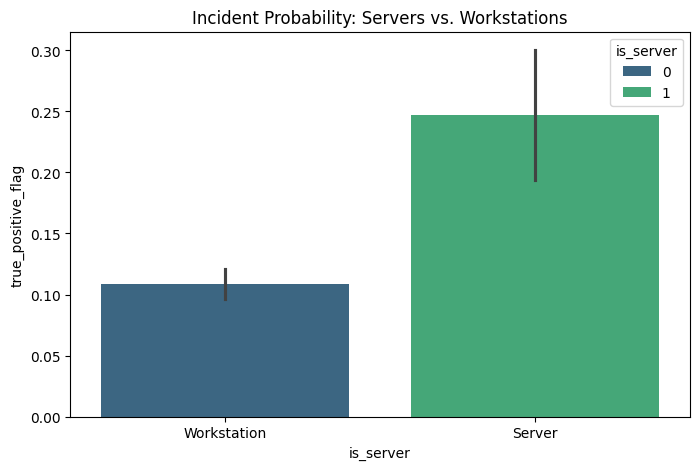

--- The Double Whammy Effect (TP Rate) ---
is_at_risk         0         1
is_server                     
0           0.060083  0.255396
1           0.147368  0.506849

--- TP Rate by OS Type ---
os_type
Windows    0.124271
Linux      0.121723
MacOS      0.119048
Name: true_positive_flag, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Cleaned Data
df = pd.read_csv('cleaned_triage_data.csv')

# --- 1. PATCH AGE VS. INCIDENTS (Correlation) ---
plt.figure(figsize=(8, 5))
# Binning patch age to see the trend more clearly
df['patch_age_bins'] = pd.cut(df['patch_age'], bins=[0, 7, 14, 21, 30, 60, 100])
sns.barplot(x='patch_age_bins', y='true_positive_flag', data=df, palette='Reds')
plt.title('True Positive Rate by Patch Age (Days)')
plt.ylabel('Probability of Incident')
plt.savefig('patch_age_correlation.png')
plt.show()

# --- 2. ASSET CRITICALITY VS. OUTCOME (Servers vs Workstations) ---
plt.figure(figsize=(8, 5))
sns.barplot(x='is_server', y='true_positive_flag', data=df, hue='is_server', palette='viridis')
plt.xticks([0, 1], ['Workstation', 'Server'])
plt.title('Incident Probability: Servers vs. Workstations')
plt.savefig('criticality_vs_outcome.png')
plt.show()

# --- 3. THE DOUBLE WHAMMY (Server + At-Risk) ---
whammy = df.groupby(['is_server', 'is_at_risk'])['true_positive_flag'].mean().unstack()
print("--- The Double Whammy Effect (TP Rate) ---")
print(whammy)

# --- 4. OS VULNERABILITY ---
os_risk = df.groupby('os_type')['true_positive_flag'].mean().sort_values(ascending=False)
print("\n--- TP Rate by OS Type ---")
print(os_risk)

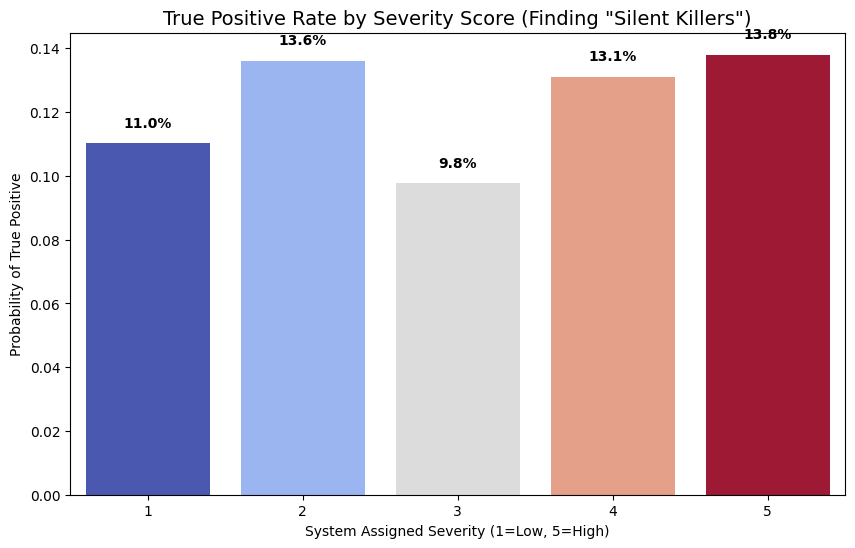

--- Silent Killer Analysis ---
Total Low Severity Alerts analyzed: 966
True Positives found in 'Low' alerts: 119
Overall TP Rate for 'Low' Alerts: 12.32%

Common Numeric Attributes of Silent Killers (Mean of Flags):
is_server       0.201681
is_at_risk      0.571429
is_off_hours    0.453782
dtype: float64

Most Common OS for Silent Killers:
Windows

OS Breakdown for Silent Killers:
os_type
Windows    0.663866
Linux      0.218487
MacOS      0.117647
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('cleaned_triage_data.csv')

# 2. CALCULATE TP RATE BY SEVERITY
# This shows if "Low" (1-2) is actually safer than "High" (4-5)
plt.figure(figsize=(10, 6))
severity_stats = df.groupby('severity_score')['true_positive_flag'].mean()

# Fix: Using 'hue' to avoid the deprecation warning
sns.barplot(x=severity_stats.index, y=severity_stats.values, hue=severity_stats.index, palette='coolwarm', legend=False)

# Add percentage labels on top of bars
for i, val in enumerate(severity_stats.values):
    plt.text(i, val + 0.005, f'{val:.1%}', ha='center', fontweight='bold')

plt.title('True Positive Rate by Severity Score (Finding "Silent Killers")', fontsize=14)
plt.ylabel('Probability of True Positive')
plt.xlabel('System Assigned Severity (1=Low, 5=High)')
plt.savefig('severity_inflation_analysis.png')
plt.show()

# 3. IDENTIFY THE "SILENT KILLERS" (Low Severity but True Positive)
silent_killers = df[(df['severity_score'] <= 2) & (df['true_positive_flag'] == 1)]

print("--- Silent Killer Analysis ---")
print(f"Total Low Severity Alerts analyzed: {len(df[df['severity_score'] <= 2])}")
print(f"True Positives found in 'Low' alerts: {len(silent_killers)}")
print(f"Overall TP Rate for 'Low' Alerts: {len(silent_killers) / len(df[df['severity_score'] <= 2]):.2%}")

# 4. DEEP DIVE INTO FEATURES (Fixed the TypeError)
# We separate Numeric means from the Categorical OS mode
print("\nCommon Numeric Attributes of Silent Killers (Mean of Flags):")
print(silent_killers[['is_server', 'is_at_risk', 'is_off_hours']].mean())

print("\nMost Common OS for Silent Killers:")
print(silent_killers['os_type'].mode()[0])

print("\nOS Breakdown for Silent Killers:")
print(silent_killers['os_type'].value_counts(normalize=True))

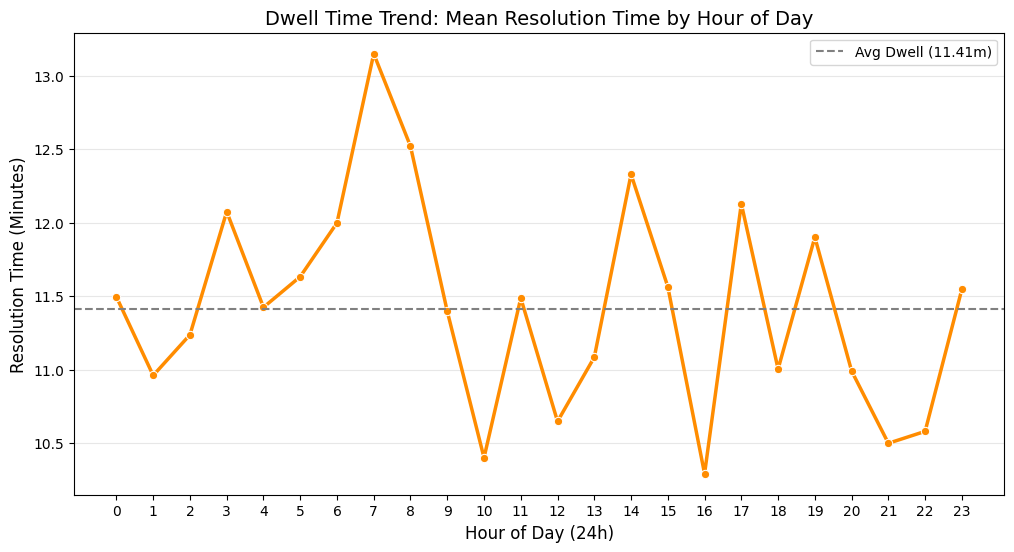

--- Dwell Time Analysis ---
Global Average Dwell Time: 11.41 minutes
Peak Bottleneck Hour: 7:00 (13.15 mins)
Most Efficient Hour: 16:00 (10.29 mins)
2:00 AM Resolution Time: 11.24 minutes


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('cleaned_triage_data.csv')

# 2. CALCULATE HOURLY RESOLUTION TIMES
# We group by hour and calculate the mean resolution time
hourly_dwell = df.groupby('hour')['resolution_time_min'].mean().reset_index()

# 3. VISUALIZATION
plt.figure(figsize=(12, 6))

# Line plot to show the "Trend"
sns.lineplot(data=hourly_dwell, x='hour', y='resolution_time_min',
             marker='o', color='darkorange', linewidth=2.5)

# Add a dashed line for the Global Average for comparison
avg_dwell = df['resolution_time_min'].mean()
plt.axhline(avg_dwell, color='gray', linestyle='--', label=f'Avg Dwell ({avg_dwell:.2f}m)')

# Formatting
plt.title('Dwell Time Trend: Mean Resolution Time by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Resolution Time (Minutes)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.savefig('dwell_time_trend.png')
plt.show()

# 4. STATISTICAL SUMMARY
max_hour = hourly_dwell.loc[hourly_dwell['resolution_time_min'].idxmax()]
min_hour = hourly_dwell.loc[hourly_dwell['resolution_time_min'].idxmin()]

print(f"--- Dwell Time Analysis ---")
print(f"Global Average Dwell Time: {avg_dwell:.2f} minutes")
print(f"Peak Bottleneck Hour: {int(max_hour['hour'])}:00 ({max_hour['resolution_time_min']:.2f} mins)")
print(f"Most Efficient Hour: {int(min_hour['hour'])}:00 ({min_hour['resolution_time_min']:.2f} mins)")

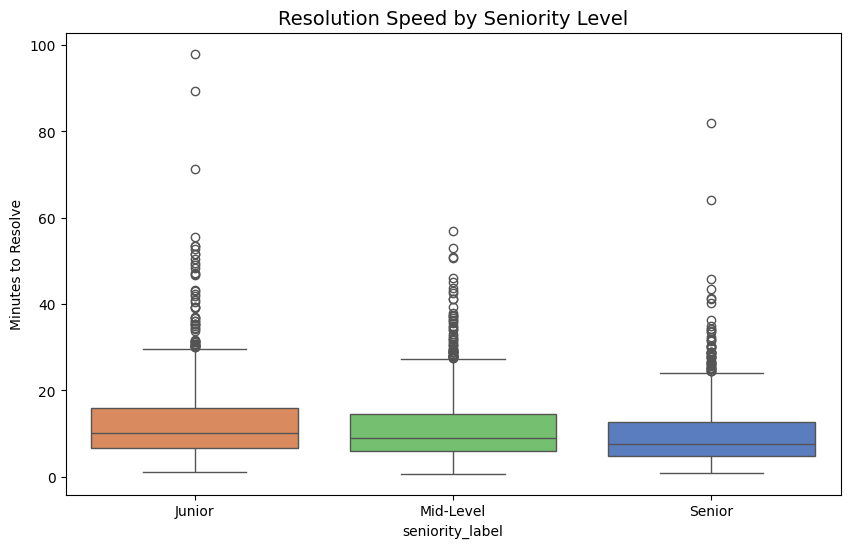


--- Triage Accuracy Gap (False Negative Rate) ---
  seniority_label  is_false_negative
0          Junior           0.012063
1       Mid-Level           0.012881
2          Senior           0.012240


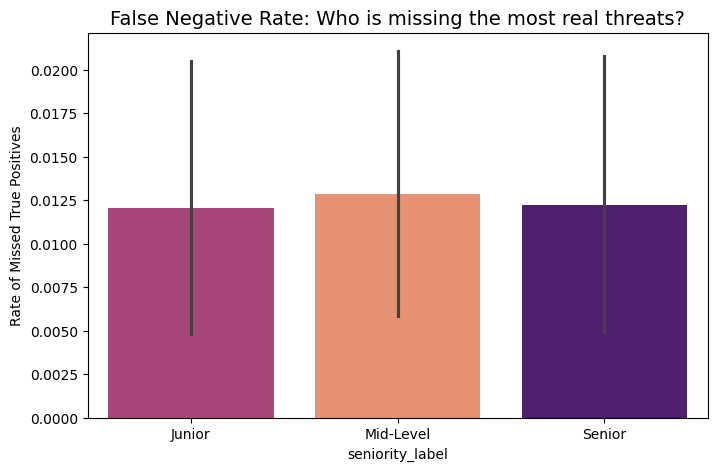


--- Average Severity Assigned by Seniority ---
  seniority_label  severity_score
0          Junior        2.980700
1       Mid-Level        3.117096
2          Senior        3.074663

--- Top 3 Most Efficient Analysts (Fastest) ---
  analyst_id seniority_label  avg_speed  total_cases
0    ANL-002          Senior   8.287268           49
1    ANL-003          Senior   8.534677           39
2    ANL-002       Mid-Level   8.575764           38

--- Bottom 3 Analysts (Slowest) ---
   analyst_id seniority_label  avg_speed  total_cases
57    ANL-020          Junior  14.520985           37
58    ANL-010          Junior  14.772301           44
59    ANL-002          Junior  15.466489           28


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('cleaned_triage_data.csv')

# --- Q1: ANALYST EFFICIENCY (Speed by Seniority) ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='seniority_label', y='resolution_time_min', data=df,
            order=['Junior', 'Mid-Level', 'Senior'], palette='muted', hue='seniority_label', legend=False)
plt.title('Resolution Speed by Seniority Level', fontsize=14)
plt.ylabel('Minutes to Resolve')
plt.savefig('efficiency_by_seniority.png')
plt.show()

# --- Q2: THE TRIAGE ACCURACY GAP (False Negatives) ---
# Logic: True Positive (Real Threat) but Action was 'Dismissed as Noise'
df['is_false_negative'] = ((df['true_positive_flag'] == 1) &
                           (df['action_type'] == 'Dismiss as Noise')).astype(int)

accuracy_gap = df.groupby('seniority_label')['is_false_negative'].mean().reset_index()
print("\n--- Triage Accuracy Gap (False Negative Rate) ---")
print(accuracy_gap)

plt.figure(figsize=(8, 5))
sns.barplot(x='seniority_label', y='is_false_negative', data=df,
            order=['Junior', 'Mid-Level', 'Senior'], palette='magma', hue='seniority_label', legend=False)
plt.title('False Negative Rate: Who is missing the most real threats?', fontsize=14)
plt.ylabel('Rate of Missed True Positives')
plt.savefig('triage_accuracy_gap.png')
plt.show()

# --- Q3: WORKLOAD DISTRIBUTION (Complexity vs. Seniority) ---
# Check if Seniors are actually getting the High Severity alerts
workload = df.groupby('seniority_label')['severity_score'].mean().reset_index()
print("\n--- Average Severity Assigned by Seniority ---")
print(workload)

# --- Q4: TOP & BOTTOM PERFORMERS (Individual IDs) ---
analyst_stats = df.groupby(['analyst_id', 'seniority_label']).agg(
    avg_speed=('resolution_time_min', 'mean'),
    total_cases=('alert_id', 'count')
).sort_values('avg_speed').reset_index()

print("\n--- Top 3 Most Efficient Analysts (Fastest) ---")
print(analyst_stats.head(3))

print("\n--- Bottom 3 Analysts (Slowest) ---")
print(analyst_stats.tail(3))